# Notebook 6: Terrain Flatness

Adds a buildability gate and flatness score. No GDAL, rasterio, or richdem — uses only `requests` and `numpy`.

| Field | Detail |
|---|---|
| Source | SRTM1 (~30m) HGT tiles from AWS public S3 bucket |
| Downsample | 3x -> ~90m (plenty for 5 km cells) |
| Slope | `numpy.gradient` with per-latitude dx correction |
| Zonal stats | Bounding-box pixel mask (cells are regular lat/lon rectangles) |
| Hard gate | `flat_frac < 0.03` -> `flatness_score = 0.0` (unbuildable) |

**Why fraction not mean slope:** A 5 km cell needs only 20-30 buildable acres. Mean slope penalises a Cascade valley cell that is mostly steep but has a large flat river terrace. Fraction below threshold asks the right question: is there enough flat land here?

**Gate at 3%:** ~185 acres of sub-5 degree terrain, roughly 6x the minimum pad size.

In [1]:
import gzip
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import requests

warnings.filterwarnings("ignore")

RAW       = Path("../data/raw")
PROCESSED = Path("../data/processed")
TILE_DIR  = RAW / "srtm_tiles"
TILE_DIR.mkdir(parents=True, exist_ok=True)

DARK_BG = "#1a1a2e"
WHITE   = "white"

plt.rcParams.update({
    "text.color": WHITE, "axes.labelcolor": WHITE,
    "xtick.color": WHITE, "ytick.color": WHITE, "font.size": 16,
})
print("Imports OK -- no GDAL/rasterio/richdem required")

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Imports OK -- no GDAL/rasterio/richdem required


## 1. Download and Stitch SRTM1 Tiles

Tiles from the AWS Open Data terrain tiles bucket (`elevation-tiles-prod`). Each `.hgt.gz` is a 3601x3601 big-endian int16 array covering exactly 1x1 degree. Tiles are cached to `data/raw/srtm_tiles/` after the first download.

WA bounding box requires lat N45-N48 (covers 45-49N) and lon W117-W125 (covers -125 to -116).

In [2]:
TILE_SIZE  = 3601     # SRTM1: 3601x3601 pixels per 1-degree tile
DOWNSAMPLE = 3        # 30m -> ~90m; reduces array ~9x
NODATA_VAL = -32768

# Stacking order: N->S for lat, W->E for lon
LAT_TILES = [48, 47, 46, 45]                               # N48 covers 48-49N (top of WA)
LON_TILES = [125, 124, 123, 122, 121, 120, 119, 118, 117]  # W125 covers -125 to -124

def download_tile(lat, lon):
    lat_tag  = f"N{lat:02d}"
    filename = f"{lat_tag}W{lon:03d}.hgt"
    path     = TILE_DIR / filename
    if path.exists():
        return path
    url = f"https://s3.amazonaws.com/elevation-tiles-prod/skadi/{lat_tag}/{filename}.gz"
    print(f"  Fetching {filename}...")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    path.write_bytes(gzip.decompress(r.content))
    return path

def load_tile(path):
    data = np.frombuffer(path.read_bytes(), dtype=">i2").reshape(TILE_SIZE, TILE_SIZE).astype(np.float32)
    data[data == NODATA_VAL] = np.nan
    return data

print(f"Downloading {len(LAT_TILES) * len(LON_TILES)} tiles (cached after first run)...")
rows = []
for lat in LAT_TILES:
    cols = []
    for lon in LON_TILES:
        tile = load_tile(download_tile(lat, lon))
        cols.append(tile[:-1, :-1])  # drop last row/col: edge overlaps adjacent tile
    rows.append(np.hstack(cols))
dem = np.vstack(rows)

# Coordinate arrays
# Row 0 = northern edge of N48 tile = 49N
# Col 0 = western edge of W125 tile = -125
NORTH = float(max(LAT_TILES) + 1)  # 49.0
WEST  = float(-max(LON_TILES))     # -125.0
RES   = DOWNSAMPLE / 3600          # degrees per pixel after downsampling

if DOWNSAMPLE > 1:
    dem = dem[::DOWNSAMPLE, ::DOWNSAMPLE]

lat_1d = NORTH - np.arange(dem.shape[0]) * RES  # descending N->S
lon_1d = WEST  + np.arange(dem.shape[1]) * RES  # ascending  W->E

print(f"DEM shape:    {dem.shape[0]} x {dem.shape[1]} pixels")
print(f"Resolution:   ~{RES * 111000:.0f} m/pixel")
print(f"Lat range:    {lat_1d[-1]:.2f}N - {lat_1d[0]:.2f}N")
print(f"Lon range:    {lon_1d[0]:.2f} - {lon_1d[-1]:.2f}")
print(f"Memory (DEM): {dem.nbytes / 1e6:.0f} MB")

DEM shape:    4800 x 10800 pixels
Resolution:   ~92 m/pixel
Lat range:    45.00N - 49.00N
Lon range:    -125.00 - -116.00
Memory (DEM): 207 MB


## 2. Compute Slope

`numpy.gradient` returns elevation change per pixel. Divide by horizontal pixel size in metres to get rise/run, then arctan for degrees.

- **dy** (N-S): constant at `RES x 110,540 m/deg`
- **dx** (E-W): varies with latitude: `RES x cos(lat) x 111,320 m/deg`

In [3]:
dy_m = RES * 110540                                                 # ~92 m at DOWNSAMPLE=3
dx_m = RES * np.cos(np.radians(lat_1d[:, np.newaxis])) * 111320    # shape (rows, 1)

# Fill NaN with median before gradient to avoid edge artifacts; re-mask afterward
dem_filled = np.where(np.isnan(dem), np.nanmedian(dem), dem)

dz_dy, dz_dx = np.gradient(dem_filled)  # dz per pixel

slope_deg = np.degrees(np.arctan(np.sqrt((dz_dx / dx_m)**2 + (dz_dy / dy_m)**2)))
slope_deg[np.isnan(dem)] = np.nan

valid = slope_deg[~np.isnan(slope_deg)]
print(f"Slope range:              {valid.min():.1f} - {valid.max():.1f} deg")
print(f"Median slope:             {np.median(valid):.1f} deg")
print(f"State-wide fraction < 5deg: {(valid < 5).mean():.3f}")

Slope range:              0.0 - 89.4 deg
Median slope:             6.9 deg
State-wide fraction < 5deg: 0.429


## 3. Zonal Statistics -- Flat Fraction per Grid Cell

Grid cells are axis-aligned rectangles in WGS84, so bounding-box pixel masking is exact. No polygon rasterisation needed.

In [4]:
wa     = gpd.read_file(RAW / "wa_state.geojson")
dc_gdf = gpd.read_file(RAW / "datacenters.geojson")
grid   = gpd.read_file("../static/grid_scores.geojson")

print(f"Grid: {len(grid)} cells")
print(f"Existing columns: {[c for c in grid.columns if c != 'geometry']}")

flat_fracs = []
for _, cell in grid.iterrows():
    minx, miny, maxx, maxy = cell.geometry.bounds

    # lat_1d is descending: negate for searchsorted
    r0 = int(np.searchsorted(-lat_1d, -maxy))      # northernmost row
    r1 = int(np.searchsorted(-lat_1d, -miny)) + 1  # southernmost row
    c0 = int(np.searchsorted(lon_1d,  minx))
    c1 = int(np.searchsorted(lon_1d,  maxx)) + 1

    r0, r1 = max(0, r0), min(dem.shape[0], r1)
    c0, c1 = max(0, c0), min(dem.shape[1], c1)

    patch = slope_deg[r0:r1, c0:c1]
    valid = patch[~np.isnan(patch)]
    flat_fracs.append(float(np.mean(valid < 5.0)) if len(valid) > 0 else 0.0)

grid["flat_frac"] = flat_fracs
print(f"flat_frac range:  {grid.flat_frac.min():.3f} - {grid.flat_frac.max():.3f}")
print(f"Median flat_frac: {grid.flat_frac.median():.3f}")

Grid: 974 cells
Existing columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geothermal_score', 'flatness_score', 'protected_score']
flat_frac range:  0.009 - 1.000
Median flat_frac: 0.350


## 4. Apply Hard Gate and Normalize

**Gate:** `flat_frac < 0.03` -> `flatness_score = 0.0`. These cells appear as a permanent dark overlay on the map regardless of slider settings.

**Score:** passing cells normalised by p95 of buildable flat fracs so the top 5% saturate at 1.0.

In [5]:
GATE = 0.03

buildable   = grid["flat_frac"] >= GATE
n_gated     = (~buildable).sum()
n_buildable = buildable.sum()

p95 = grid.loc[buildable, "flat_frac"].quantile(0.95)
grid["flatness_score"] = 0.0
grid.loc[buildable, "flatness_score"] = (
    grid.loc[buildable, "flat_frac"] / p95
).clip(0, 1)

print(f"Gate:            flat_frac >= {GATE:.0%}  (~{GATE * 6177:.0f} buildable acres needed)")
print(f"Gated (unbuild): {n_gated} cells  ({n_gated  / len(grid):.1%})")
print(f"Buildable:       {n_buildable} cells  ({n_buildable / len(grid):.1%})")
print(f"p95 flat_frac:   {p95:.3f}")
print(f"flatness_score (buildable): "
      f"{grid.loc[buildable,'flatness_score'].min():.3f} - "
      f"{grid.loc[buildable,'flatness_score'].max():.3f}")

Gate:            flat_frac >= 3%  (~185 buildable acres needed)
Gated (unbuild): 61 cells  (6.3%)
Buildable:       913 cells  (93.7%)
p95 flat_frac:   0.948
flatness_score (buildable): 0.032 - 1.000


## 5. Map

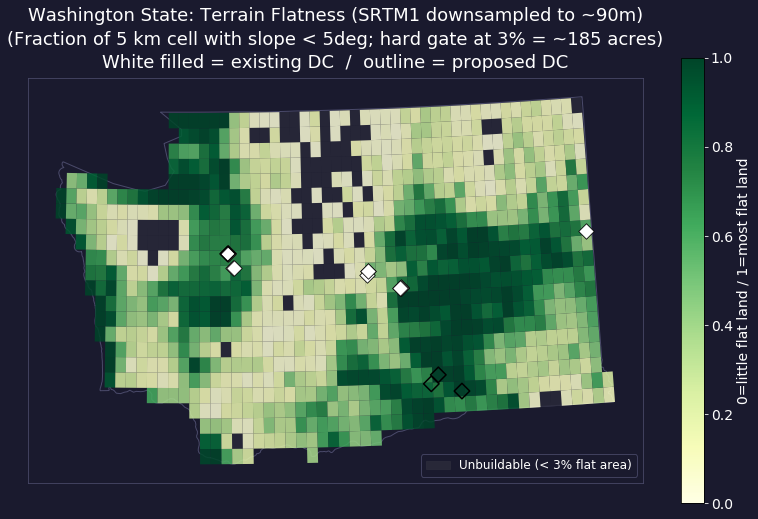

Saved to data/processed/terrain_flatness.png and static/img/terrain_flatness.png


In [6]:
import shutil

wa_plot    = wa.to_crs("EPSG:32610")
dc_plot    = dc_gdf.to_crs("EPSG:32610")
grid_plot  = grid.to_crs("EPSG:32610")
build_plot = grid_plot[buildable]
gated_plot = grid_plot[~buildable]

fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)
wa_plot.boundary.plot(ax=ax, color="#4a4a6a", linewidth=1.0, zorder=1)

if len(gated_plot) > 0:
    gated_plot.plot(ax=ax, color="#2a2a3a", alpha=0.80, zorder=2)

n_before = len(fig.axes)
build_plot.plot(
    column="flatness_score", ax=ax, cmap="YlGn", vmin=0, vmax=1,
    legend=True,
    legend_kwds={"shrink": 0.65, "label": "0=little flat land / 1=most flat land"},
    alpha=0.85, zorder=3
)
if len(fig.axes) > n_before:
    cb = fig.axes[-1]
    cb.tick_params(labelsize=14, colors=WHITE)
    cb.yaxis.label.set_color(WHITE)
    cb.yaxis.label.set_size(14)

_rep  = dc_plot[dc_plot["source"] == "reported"]
_prop = dc_plot[dc_plot["source"] == "proposed"]
ax.scatter(_rep.geometry.x,  _rep.geometry.y,
           c=WHITE, s=120, marker="D", zorder=5, edgecolors="black", linewidths=0.8)
ax.scatter(_prop.geometry.x, _prop.geometry.y,
           facecolors="none", s=120, marker="D", zorder=5, edgecolors="black", linewidths=1.5)

gated_patch = mpatches.Patch(color="#2a2a3a", alpha=0.9,
                              label=f"Unbuildable (< {GATE:.0%} flat area)")
leg = ax.legend(handles=[gated_patch], loc="lower right",
                facecolor="#1a1a2e", edgecolor="#4a4a6a", fontsize=12)
for text in leg.get_texts():
    text.set_color(WHITE)

ax.set_title(
    "Washington State: Terrain Flatness (SRTM1 downsampled to ~90m)\n"
    "(Fraction of 5 km cell with slope < 5deg; hard gate at 3% = ~185 acres)\n"
    "White filled = existing DC  /  outline = proposed DC",
    color=WHITE, fontsize=18, pad=10, linespacing=1.4
)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor("#4a4a6a")

plt.tight_layout()
out_proc = PROCESSED / "terrain_flatness.png"
out_web  = Path("../static/img/terrain_flatness.png")
plt.savefig(out_proc, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
shutil.copy(out_proc, out_web)
plt.show()
print(f"Saved to {out_proc} and {out_web}")

## 6. Key Findings

In [7]:
grid["centroid"] = grid.geometry.centroid

def nearest_cell(pt):
    dists = grid.centroid.apply(lambda c: pt.distance(c))
    return grid.loc[dists.idxmin()]

print("=== Proposed Sites ===")
for _, row in dc_gdf[dc_gdf["source"] == "proposed"].iterrows():
    n = nearest_cell(row.geometry)
    status = "BUILDABLE" if n.flat_frac >= GATE else "GATED (unbuildable)"
    print(f'  {row["name"]}:\n'
          f'    flat_frac={n.flat_frac:.3f}  flatness_score={n.flatness_score:.3f}  [{status}]\n')

print("=== Existing Clusters ===")
seen = set()
for _, row in dc_gdf[dc_gdf["source"] == "reported"].iterrows():
    n = nearest_cell(row.geometry)
    key = round(n.flat_frac, 3)
    if key in seen:
        continue
    seen.add(key)
    status = "BUILDABLE" if n.flat_frac >= GATE else "GATED (unbuildable)"
    print(f'  {row["name"]}:\n'
          f'    flat_frac={n.flat_frac:.3f}  flatness_score={n.flatness_score:.3f}  [{status}]\n')

=== Proposed Sites ===
  Digital Realty (proposed):
    flat_frac=0.669  flatness_score=0.705  [BUILDABLE]

  Amazon Wallula Gap (proposed):
    flat_frac=0.949  flatness_score=1.000  [BUILDABLE]

  Atlas Agro Richland DC1 (proposed):
    flat_frac=0.957  flatness_score=1.000  [BUILDABLE]

  Trammell Crow Lewis Clark (proposed):
    flat_frac=0.790  flatness_score=0.833  [BUILDABLE]

=== Existing Clusters ===
  Microsoft Quincy Campus:
    flat_frac=0.728  flatness_score=0.769  [BUILDABLE]

  Microsoft EAT06/EAT09:
    flat_frac=0.454  flatness_score=0.479  [BUILDABLE]

  Equinix SE2 Seattle:
    flat_frac=0.669  flatness_score=0.705  [BUILDABLE]

  HorizonIQ Seattle (Tukwila):
    flat_frac=0.784  flatness_score=0.828  [BUILDABLE]

  Verizon Liberty Lake:
    flat_frac=0.535  flatness_score=0.564  [BUILDABLE]



## 7. Export Updated grid_scores.geojson

In [8]:
grid_out = grid.drop(columns=["centroid", "flat_frac"], errors="ignore")
grid_out.to_file("../static/grid_scores.geojson", driver="GeoJSON")
print("Saved ../static/grid_scores.geojson")
print(f"Columns: {list(grid_out.columns)}")

Saved ../static/grid_scores.geojson
Columns: ['cell_id', 'tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'contamination_score', 'waterway_score', 'geothermal_score', 'flatness_score', 'protected_score', 'geometry']
